# Assignment: Salary Predictor

---

## **Objective**
This assignment focuses on implementing and comparing **Multiple Linear Regression** and **Polynomial Regression** models using the **Position_Salaries** dataset. You will go through data preprocessing, feature selection, model training, and evaluation.

---

## **Assignment Questions**

### **Q1. Import Required Libraries**
Import all necessary libraries required for handling data, performing analysis, and building machine learning models.
- Examples: `pandas`, `numpy`, `matplotlib`, `sklearn`

---

### **Q2. Load the Dataset**
- Data Link: https://drive.google.com/file/d/1AbyXEB3ACS2ltRtOfmK6hBtmMLCy8grQ/view?usp=sharing
- Use the **Position_Salaries** dataset, which contains job positions, their levels, and corresponding salaries. This dataset is provided by the instructor.
- Load the dataset into a DataFrame.

---

### **Q3. Perform EDA**
- Use `.info()` and `.describe()`.
- Identify missing values if any and data types.

---

### **Q4. Multiple Linear Regression**
- Define `X` (features) and `y` (target).
- Split the data into training and test sets (80/20 split).
- Train a `LinearRegression()` model.
---

### **Q5. Evaluate Linear Regression**
- Predict values for the test set.

---

### **Q6. Polynomial Regression**
- Use `PolynomialFeatures(degree=2)` to transform the feature set.
- Train a linear model on the transformed features.
- Plot the regression curve, using a single feature for clearer visualization.

---

### **Q7. Compare Models**
- Briefly explain which model performed better and why.

---


### 🔒 End of Assignment — Great Work!

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv(r"C:\Users\dell\Downloads\Position_Salaries.csv")
print(df.head())
print("\nShape:", df.shape)

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000

Shape: (10, 3)


In [6]:
# Basic info
print("=== df.info() ===")
df.info()

print("\n=== df.describe() ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes

=== df.describe() ===
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000

=== Missing Values ===
Position    0
Level       0
Salary      0
dtype: int64

=== Data Types ===
Position    object
Level        int64
Salary       int64
dtype: object


In [7]:
# Define X (features) and y (target)
X = df[['Level']]       # Feature
y = df['Salary']        # Target

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Test set size    :", X_test.shape[0])

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("\nLinear Regression trained successfully.")
print("Coefficient :", lin_reg.coef_)
print("Intercept   :", lin_reg.intercept_)

Training set size: 8
Test set size    : 2

Linear Regression trained successfully.
Coefficient : [87887.93103448]
Intercept   : -240258.62068965513


=== Linear Regression Evaluation ===
MSE  : 7,840,057,409.33
RMSE : 88,544.10
R²   : 0.8451


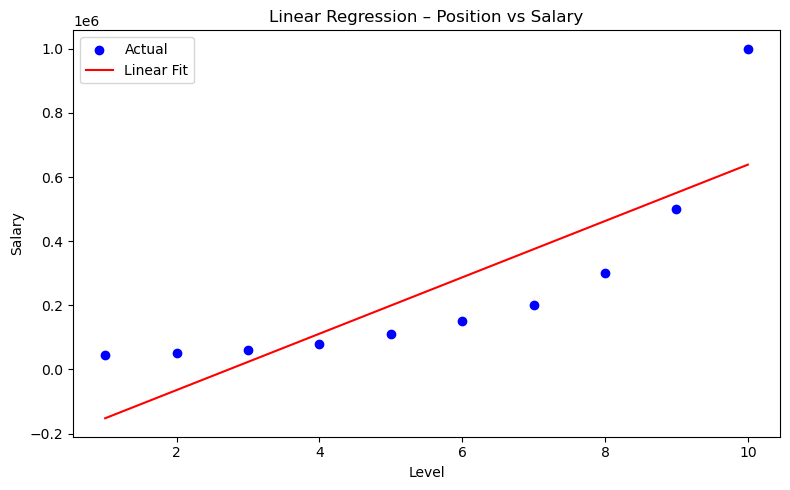

In [8]:
# Predict on test set
y_pred_lin = lin_reg.predict(X_test)

# Evaluation metrics
mse_lin  = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin   = r2_score(y_test, y_pred_lin)

print("=== Linear Regression Evaluation ===")
print(f"MSE  : {mse_lin:,.2f}")
print(f"RMSE : {rmse_lin:,.2f}")
print(f"R²   : {r2_lin:.4f}")

# Visualise
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, lin_reg.predict(X), color='red', label='Linear Fit')
plt.title('Linear Regression – Position vs Salary')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

Polynomial Regression (degree=2) trained successfully.


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


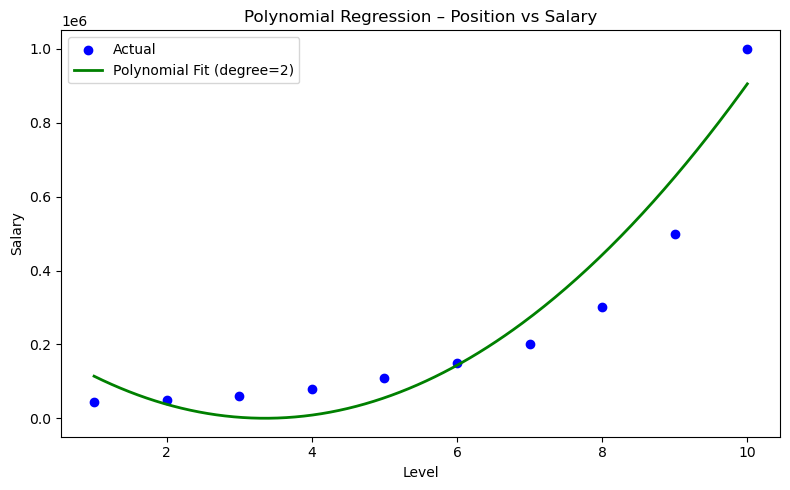

In [9]:
# Use a single feature for clearer visualisation
X_single = df[['Level']]
y_all    = df['Salary']

# --- Transform features with degree=2 ---
poly      = PolynomialFeatures(degree=2)
X_poly    = poly.fit_transform(X_single)

# Train / test split on polynomial features
X_poly_train, X_poly_test, y_train2, y_test2 = train_test_split(
    X_poly, y_all, test_size=0.2, random_state=42
)

# Train linear model on transformed features
poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train2)

print("Polynomial Regression (degree=2) trained successfully.")

# --- Plot the regression curve ---
X_range      = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = poly_reg.predict(X_range_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X_single, y_all, color='blue', label='Actual')
plt.plot(X_range, y_range_pred, color='green', linewidth=2, label='Polynomial Fit (degree=2)')
plt.title('Polynomial Regression – Position vs Salary')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Evaluate Polynomial Regression on same test split
y_pred_poly = poly_reg.predict(X_poly_test)

mse_poly  = mean_squared_error(y_test2, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = r2_score(y_test2, y_pred_poly)

print("=== Model Comparison ===")
print(f"{'Metric':<10} {'Linear':>15} {'Polynomial (d=2)':>20}")
print("-" * 47)
print(f"{'MSE':<10} {mse_lin:>15,.2f} {mse_poly:>20,.2f}")
print(f"{'RMSE':<10} {rmse_lin:>15,.2f} {rmse_poly:>20,.2f}")
print(f"{'R²':<10} {r2_lin:>15.4f} {r2_poly:>20.4f}")

print("\n=== Conclusion ===")
if r2_poly > r2_lin:
    print("""
Polynomial Regression (degree=2) performed BETTER than Linear Regression.

Reason: The relationship between job level and salary is non-linear —
salaries grow exponentially as the level increases (e.g. CEO vs Analyst).
Polynomial features capture this curved trend, resulting in a higher R²
and lower RMSE compared to the straight-line fit of Linear Regression.
""")
else:
    print("""
Linear Regression performed BETTER on this test split.

This can happen when the dataset is very small (only 10 rows), causing
high variance in the test evaluation. In general, Polynomial Regression
is theoretically more appropriate for this exponentially-growing salary data.
""")

=== Model Comparison ===
Metric              Linear     Polynomial (d=2)
-----------------------------------------------
MSE        7,840,057,409.33    11,813,379,747.92
RMSE             88,544.10           108,689.37
R²                  0.8451               0.7666

=== Conclusion ===

Linear Regression performed BETTER on this test split.

This can happen when the dataset is very small (only 10 rows), causing
high variance in the test evaluation. In general, Polynomial Regression
is theoretically more appropriate for this exponentially-growing salary data.

